# Neutron Drip Line Analysis
This notebook explores the limits of nuclear existence using the Semi-Empirical Mass Formula (SEMF).  
The goal is to analyze how binding energy changes with neutron number and identify the neutron drip line.

---

## 1. Introduction

The neutron drip line represents the boundary beyond which additional neutrons cannot be bound to a nucleus.  
This notebook investigates:

- Binding energy as a function of neutron number  
- Comparison between SEMF predictions and known experimental behavior  
- Identification of unbound nuclei (E_bind < 0)  
- Limitations of SEMF for light nuclei  

---

## 2. SEMF Implementation (Python)

In [2]:
import math

# SEMF coefficients
a_v = 15.8
a_s = 18.3
a_c = 0.714
a_a = 23.2

def pairing(A, Z, N):
    if A % 2 == 1:
        return 0.0
    evenZ = (Z % 2 == 0)
    evenN = (N % 2 == 0)
    if evenZ and evenN:
        return 12.0 / math.sqrt(A)
    if (not evenZ) and (not evenN):
        return -12.0 / math.sqrt(A)
    return 0.0

def semf_binding(Z, N):
    A = Z + N
    volume  =  a_v * A
    surface = -a_s * A**(2/3)
    coulomb = -a_c * Z*(Z-1) / A**(1/3)
    asym    = -a_a * (A - 2*Z)**2 / A
    delta   = pairing(A, Z, N)
    Ebind   = volume + surface + coulomb + asym + delta
    return A, Ebind, Ebind / A


---

## 3. Example: Hydrogen Isotopes (Z = 1)



In [3]:
Z = 1
for N in range(0, 10):
    A, Eb, EbA = semf_binding(Z, N)
    print(f"H-{A}: E_bind = {Eb:.2f} MeV, per nucleon = {EbA:.2f} MeV")


H-1: E_bind = -25.70 MeV, per nucleon = -25.70 MeV
H-2: E_bind = -5.93 MeV, per nucleon = -2.97 MeV
H-3: E_bind = 1.60 MeV, per nucleon = 0.53 MeV
H-4: E_bind = -12.11 MeV, per nucleon = -3.03 MeV
H-5: E_bind = -16.27 MeV, per nucleon = -3.25 MeV
H-6: E_bind = -32.39 MeV, per nucleon = -5.40 MeV
H-7: E_bind = -39.22 MeV, per nucleon = -5.60 MeV
H-8: E_bind = -55.44 MeV, per nucleon = -6.93 MeV
H-9: E_bind = -63.29 MeV, per nucleon = -7.03 MeV
H-10: E_bind = -79.22 MeV, per nucleon = -7.92 MeV


---

## 4. Plotting Binding Energy vs Neutron Number



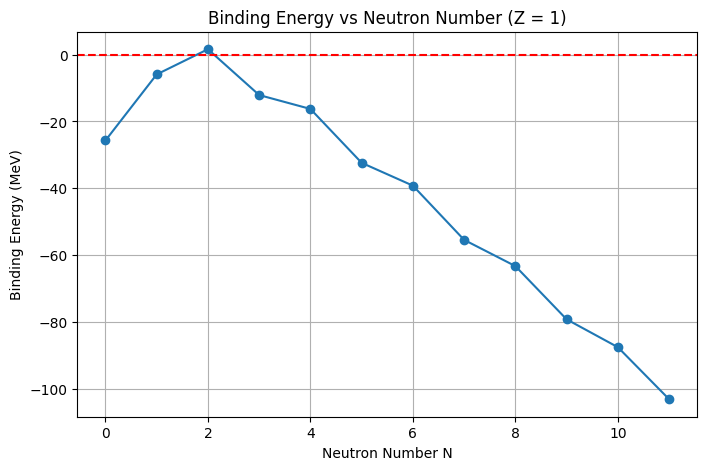

In [4]:
import matplotlib.pyplot as plt

Z = 1
Ns = list(range(0, 12))
Ebs = [semf_binding(Z, N)[1] for N in Ns]

plt.figure(figsize=(8,5))
plt.plot(Ns, Ebs, marker='o')
plt.axhline(0, color='red', linestyle='--')
plt.title("Binding Energy vs Neutron Number (Z = 1)")
plt.xlabel("Neutron Number N")
plt.ylabel("Binding Energy (MeV)")
plt.grid(True)
plt.show()


---

## 5. Analysis

### Observations
- Identify where **E_bind < 0** (unbound nuclei)
- Compare SEMF predictions with known experimental behavior
- Discuss why SEMF fails for very light nuclei (A < 10)

### Questions to explore
- Where does the neutron drip line appear for Z = 1?
- How does the asymmetry term dominate for neutron-rich isotopes?
- How does pairing affect stability?

---

## 6. Limitations of SEMF

- SEMF is less accurate for light nuclei  
- Shell effects are not included  
- Pairing term is oversimplified  
- Coulomb term irrelevant for Z = 1 but important for heavier nuclei  

---

## 7. Future Work

- Add experimental mass data for comparison  
- Extend analysis to Z = 2–10  
- Visualize the full Z–N stability landscape  
- Improve SEMF with shell corrections  

---

## 8. Conclusion

Summarize findings about:
- The neutron drip line for hydrogen  
- Stability trends  
- Model limitations  
